# AtmoGraph — Supply Chain Ripple Effect Predictor
**Project 2 · Advanced Data Science & ML Engineering · Infotact Solutions**

Traditional supply-chain forecasting treats each product line as an isolated time series.
**AtmoGraph** instead models the global supply chain as a graph — suppliers, ports,
manufacturers, and consumer markets as nodes, shipping/sourcing relationships as edges —
and uses a **Graph Neural Network (GNN)** to predict how a localized disruption (e.g. a port
strike in Europe) ripples multiple hops downstream to affect unrelated industries.

**Pipeline covered in this notebook:**

1. **Graph Foundations** — build the global supply-chain graph (mock data here; production uses **Neo4j**)
2. **NLP Ingestion Engine** — extract disruption events from live news text (**spaCy**)
3. **Graph Neural Network** — predict multi-hop ripple delays (**PyTorch**, GCN architecture — swap-in ready for **PyTorch Geometric** at scale)
4. **Real-Time Simulation** — feed a live "news event" through the pipeline end-to-end
5. **Interactive-style Visualization** — risk heatmap over the network + most-affected industries

> This notebook uses in-memory mock data and a lightweight hand-rolled GCN so it runs
> anywhere without external services. Section 1 and Section 3 include drop-in notes for
> swapping to a real **Neo4j** instance and **PyTorch Geometric**, per the project spec.


## 0. Setup

In [1]:
import random
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

import torch
import torch.nn as nn
import torch.nn.functional as F

import spacy

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

%matplotlib inline
plt.rcParams["figure.facecolor"] = "white"


## 1. Graph Foundations — the Global Supply Chain Graph

We model four node types:

| Type | Role |
|---|---|
| `supplier` | Raw material / component supplier |
| `port` | Regional shipping hub |
| `manufacturer` | Assembles goods for an industry |
| `market` | Downstream consumer market |

Edges represent the flow of goods: `supplier → port → manufacturer → market`.

> **Neo4j in production:** this exact structure maps directly onto a Neo4j property graph.
> A Cypher ingestion script is included (commented out) below — point it at a running
> Neo4j instance (`bolt://localhost:7687`) to persist and query the graph at scale instead
> of the in-memory `networkx.DiGraph` used here for portability.


In [2]:
INDUSTRIES = ["Consumer Electronics", "Automotive", "Pharma",
              "Textiles", "Agriculture", "Semiconductors"]
REGIONS = ["North America", "Europe", "East Asia", "South Asia", "South America"]

G = nx.DiGraph()
_node_id = 0

def add_node(name, ntype, region, industry, base_risk=0.05):
    global _node_id
    nid = f"N{_node_id}"
    _node_id += 1
    G.add_node(nid, name=name, type=ntype, region=region,
               industry=industry, risk=base_risk,
               capacity=round(random.uniform(0.5, 1.0), 2))
    return nid

# Regional ports
ports = [add_node(f"Port of {r}", "port", r, "Logistics") for r in REGIONS]

# Manufacturers: each industry has plants in 2 regions
manufacturers = []
for ind in INDUSTRIES:
    for r in random.sample(REGIONS, 2):
        manufacturers.append(add_node(f"{ind} Mfg ({r})", "manufacturer", r, ind))

# Suppliers feeding each manufacturer
suppliers = []
for m in manufacturers:
    for _ in range(random.randint(1, 2)):
        r = G.nodes[m]["region"]
        suppliers.append(add_node(f"Supplier -> {G.nodes[m]['name']}", "supplier",
                                   r, G.nodes[m]["industry"]))

# Consumer markets (NA demand, for simplicity) per industry
markets = [add_node(f"{ind} Consumer Market (NA)", "market", "North America", ind)
           for ind in INDUSTRIES]

# Edges: supplier -> same-region port
for s in suppliers:
    same_region_ports = [p for p in ports if G.nodes[p]["region"] == G.nodes[s]["region"]]
    if same_region_ports:
        G.add_edge(s, random.choice(same_region_ports), weight=1.0)

# Edges: port -> manufacturer (cross-region shipping, sparsely connected)
for p in ports:
    for m in manufacturers:
        if random.random() < 0.35:
            G.add_edge(p, m, weight=round(random.uniform(0.3, 1.0), 2))

# Edges: manufacturer -> its industry's consumer market
for m in manufacturers:
    for mkt in markets:
        if G.nodes[mkt]["industry"] == G.nodes[m]["industry"]:
            G.add_edge(m, mkt, weight=1.0)

print(f"Graph built: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
pd.Series([d['type'] for _, d in G.nodes(data=True)]).value_counts()


Graph built: 41 nodes, 58 edges


supplier        18
manufacturer    12
market           6
port             5
Name: count, dtype: int64

In [3]:
# --- Neo4j ingestion (production drop-in) --------------------------------
# from neo4j import GraphDatabase
#
# driver = GraphDatabase.driver("bolt://localhost:7687", auth=("neo4j", "password"))
#
# def push_graph_to_neo4j(G, driver):
#     with driver.session() as session:
#         for nid, d in G.nodes(data=True):
#             session.run(
#                 "MERGE (n:Node {id: $id}) "
#                 "SET n.name=$name, n.type=$type, n.region=$region, "
#                 "n.industry=$industry, n.risk=$risk, n.capacity=$capacity",
#                 id=nid, **d
#             )
#         for u, v, d in G.edges(data=True):
#             session.run(
#                 "MATCH (a:Node {id:$u}),(b:Node {id:$v}) "
#                 "MERGE (a)-[r:SHIPS_TO]->(b) SET r.weight=$weight",
#                 u=u, v=v, weight=d.get("weight", 1.0)
#             )
#
# push_graph_to_neo4j(G, driver)
# ---------------------------------------------------------------------------
print("Neo4j ingestion stubbed above — uncomment and point at a live instance to persist the graph.")

Neo4j ingestion stubbed above — uncomment and point at a live instance to persist the graph.


## 2. NLP Ingestion Engine — Extracting Disruptions from News

A live news-monitoring pipeline scrapes headlines and needs to (a) recognize that an
event is a **supply-chain disruption**, (b) locate it geographically, and (c) map it onto
the graph so downstream modules can react.

Here we use **spaCy** with a rule-based `EntityRuler` (regions, industries, and disruption
phrases like *"port strike"*, *"factory fire"*, *"shortage"*). This keeps the notebook
fully offline/reproducible; in production, swap in a fine-tuned `en_core_web_trf` /
HuggingFace NER model for open-vocabulary entity extraction from noisy real news text.


In [4]:
nlp = spacy.blank("en")
ruler = nlp.add_pipe("entity_ruler")

patterns = (
    [{"label": "REGION", "pattern": r} for r in REGIONS] +
    [{"label": "INDUSTRY", "pattern": i} for i in INDUSTRIES] +
    [
        {"label": "DISRUPTION_EVENT", "pattern": [{"LOWER": "port"}, {"LOWER": "strike"}]},
        {"label": "DISRUPTION_EVENT", "pattern": [{"LOWER": "factory"}, {"LOWER": "fire"}]},
        {"label": "DISRUPTION_EVENT", "pattern": [{"LOWER": "flood"}]},
        {"label": "DISRUPTION_EVENT", "pattern": [{"LOWER": "shortage"}]},
        {"label": "DISRUPTION_EVENT", "pattern": [{"LOWER": "earthquake"}]},
    ]
)
ruler.add_patterns(patterns)

def extract_disruption(headline: str):
    doc = nlp(headline)
    return {
        "regions": [e.text for e in doc.ents if e.label_ == "REGION"],
        "industries": [e.text for e in doc.ents if e.label_ == "INDUSTRY"],
        "events": [e.text for e in doc.ents if e.label_ == "DISRUPTION_EVENT"],
    }

sample_headline = "A sudden port strike has broken out in Europe, halting shipments across the region."
extract_disruption(sample_headline)

{'regions': ['Europe'], 'industries': [], 'events': ['port strike']}

In [5]:
def ingest_news_event(G, headline: str, severity: float = 0.8):
    """Parse a headline and raise the risk score on matching port node(s) in the graph."""
    parsed = extract_disruption(headline)
    affected = []
    if parsed["regions"] and parsed["events"]:
        for nid, d in G.nodes(data=True):
            if d["type"] == "port" and d["region"] in parsed["regions"]:
                G.nodes[nid]["risk"] = min(1.0, d["risk"] + severity)
                affected.append(nid)
    return affected, parsed

affected_nodes, parsed = ingest_news_event(G, sample_headline)
print("Parsed:", parsed)
print("Risk updated on:", [G.nodes[n]["name"] for n in affected_nodes])

Parsed: {'regions': ['Europe'], 'industries': [], 'events': ['port strike']}
Risk updated on: ['Port of Europe']


## 3. Graph Neural Network — Predicting the Ripple Effect

We convert the graph into a feature matrix `X` (risk, capacity, one-hot type, one-hot
industry) and a normalized adjacency matrix `Â` (symmetric, self-loops, degree-normalized —
the standard **Kipf & Welling GCN** propagation rule):

$$H^{(l+1)} = \text{ReLU}\left(\hat{A} H^{(l)} W^{(l)}\right)$$

Stacking layers lets risk propagate across **multiple hops** — exactly the "ripple effect"
we need (a port strike affects the manufacturer 1 hop away, and the consumer market 2 hops
away).

> **PyTorch Geometric in production:** the hand-rolled `GCNLayer` below is written in
> plain PyTorch (dense adjacency) so the notebook has zero extra dependencies and trains
> in milliseconds on this toy graph. At real-world scale (thousands–millions of nodes),
> replace `GCNLayer` with `torch_geometric.nn.GCNConv` / `SAGEConv` operating on a sparse
> `edge_index`, which is a drop-in swap since the forward-pass math is identical.


In [6]:
nodes_list = list(G.nodes())
idx_of = {n: i for i, n in enumerate(nodes_list)}
N = len(nodes_list)

# --- Adjacency (undirected view for message passing), self-loops, symmetric norm ---
A = np.zeros((N, N), dtype=np.float32)
for u, v in G.edges():
    A[idx_of[u], idx_of[v]] = 1.0
    A[idx_of[v], idx_of[u]] = 1.0
A += np.eye(N, dtype=np.float32)
deg = A.sum(axis=1)
D_inv_sqrt = np.diag(1.0 / np.sqrt(deg))
A_norm = torch.tensor(D_inv_sqrt @ A @ D_inv_sqrt, dtype=torch.float32)

# --- Node feature matrix ---
TYPES = ["supplier", "port", "manufacturer", "market"]
type_to_idx = {t: i for i, t in enumerate(TYPES)}
INDUSTRIES_EXT = INDUSTRIES + ["Logistics"]
industry_to_idx = {ind: i for i, ind in enumerate(INDUSTRIES_EXT)}

X = np.zeros((N, 2 + len(TYPES) + len(INDUSTRIES_EXT)), dtype=np.float32)
for n, d in G.nodes(data=True):
    i = idx_of[n]
    X[i, 0] = d["risk"]
    X[i, 1] = d["capacity"]
    X[i, 2 + type_to_idx[d["type"]]] = 1.0
    X[i, 2 + len(TYPES) + industry_to_idx[d["industry"]]] = 1.0
X = torch.tensor(X, dtype=torch.float32)

print("Feature matrix:", X.shape, "| Adjacency:", A_norm.shape)

Feature matrix: torch.Size([41, 13]) | Adjacency: torch.Size([41, 41])


In [7]:
# --- Synthetic ground-truth labels -----------------------------------------
# In production these labels come from historical logistics data (actual observed
# delay days per node, following a real disruption). Here we simulate them via
# multi-hop diffusion of the current risk scores, so the GNN has a clear signal
# to learn: "delay(node) increases with upstream risk, decaying with distance".
risk_vec = X[:, 0].numpy()
sim_delay = risk_vec.copy()
A_np = A_norm.numpy()
for _ in range(3):  # 3-hop propagation horizon
    sim_delay = 0.6 * sim_delay + 0.4 * (A_np @ sim_delay)
sim_delay = sim_delay * 90.0  # scale into "days of predicted delay"
y = torch.tensor(sim_delay, dtype=torch.float32).unsqueeze(1)

epoch   0 | MSE loss 83.090
epoch  40 | MSE loss 23.385
epoch  80 | MSE loss 12.342
epoch 120 | MSE loss 5.784


epoch 160 | MSE loss 4.327


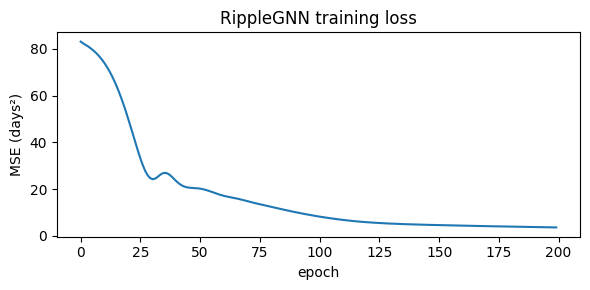

In [8]:
class GCNLayer(nn.Module):
    """Single graph-convolution layer: H' = A_norm @ H @ W (+ bias)."""
    def __init__(self, in_f, out_f):
        super().__init__()
        self.lin = nn.Linear(in_f, out_f)

    def forward(self, X, A_norm):
        return self.lin(A_norm @ X)


class RippleGNN(nn.Module):
    """2-layer GCN regressor: node features -> predicted downstream delay (days)."""
    def __init__(self, in_f, hidden=16, out_f=1):
        super().__init__()
        self.gc1 = GCNLayer(in_f, hidden)
        self.gc2 = GCNLayer(hidden, hidden)
        self.out = nn.Linear(hidden, out_f)

    def forward(self, X, A_norm):
        h = F.relu(self.gc1(X, A_norm))
        h = F.relu(self.gc2(h, A_norm))
        return self.out(h)


model = RippleGNN(in_f=X.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

history = []
for epoch in range(200):
    model.train()
    optimizer.zero_grad()
    pred = model(X, A_norm)
    loss = loss_fn(pred, y)
    loss.backward()
    optimizer.step()
    history.append(loss.item())
    if epoch % 40 == 0:
        print(f"epoch {epoch:>3} | MSE loss {loss.item():.3f}")

plt.figure(figsize=(6, 3))
plt.plot(history)
plt.title("RippleGNN training loss")
plt.xlabel("epoch"); plt.ylabel("MSE (days²)")
plt.tight_layout()
plt.show()

## 4. Real-Time Simulation — Live Ripple-Effect Inference

This mirrors the production FastAPI/WebSocket flow: a news headline comes in →
NLP ingestion updates node risk → the trained GNN re-scores every node in the graph →
the dashboard highlights newly at-risk nodes.


In [9]:
def predict_delays(model, G, X_template_fn):
    """Rebuild the feature matrix from current graph state and run inference."""
    X_live = X_template_fn(G)
    model.eval()
    with torch.no_grad():
        preds = model(X_live, A_norm).squeeze().numpy()
    return preds

def build_feature_matrix(G):
    Xl = np.zeros((N, 2 + len(TYPES) + len(INDUSTRIES_EXT)), dtype=np.float32)
    for n, d in G.nodes(data=True):
        i = idx_of[n]
        Xl[i, 0] = d["risk"]
        Xl[i, 1] = d["capacity"]
        Xl[i, 2 + type_to_idx[d["type"]]] = 1.0
        Xl[i, 2 + len(TYPES) + industry_to_idx[d["industry"]]] = 1.0
    return torch.tensor(Xl, dtype=torch.float32)

# --- Simulate a fresh breaking-news event -----------------------------------
breaking_news = "Factory fire disrupts Semiconductors production across East Asia."
affected_nodes, parsed = ingest_news_event(G, breaking_news, severity=0.9)
print("Parsed event:", parsed)
print("Directly affected nodes:", [G.nodes[n]["name"] for n in affected_nodes])

pred_delays = predict_delays(model, G, build_feature_matrix)

results = pd.DataFrame({
    "node": [G.nodes[n]["name"] for n in nodes_list],
    "type": [G.nodes[n]["type"] for n in nodes_list],
    "industry": [G.nodes[n]["industry"] for n in nodes_list],
    "region": [G.nodes[n]["region"] for n in nodes_list],
    "predicted_delay_days": pred_delays,
}).sort_values("predicted_delay_days", ascending=False)

results.head(10)

Parsed event: {'regions': ['East Asia'], 'industries': ['Semiconductors'], 'events': ['Factory fire']}
Directly affected nodes: ['Port of East Asia']


,node,type,industry,region,predicted_delay_days
1,Port of Europe,port,Logistics,Europe,28.313107
27,Supplier -> Textiles Mfg (Europe),supplier,Textiles,Europe,13.343515
28,Supplier -> Textiles Mfg (Europe),supplier,Textiles,Europe,13.341141
21,Supplier -> Automotive Mfg (Europe),supplier,Automotive,Europe,13.145294
33,Supplier -> Semiconductors Mfg (Europe),supplier,Semiconductors,Europe,13.051990
32,Supplier -> Semiconductors Mfg (Europe),supplier,Semiconductors,Europe,13.045657
30,Supplier -> Agriculture Mfg (Europe),supplier,Agriculture,Europe,12.864458
31,Supplier -> Agriculture Mfg (Europe),supplier,Agriculture,Europe,12.858917
4,Port of South America,port,Logistics,South America,11.825169
25,Supplier -> Pharma Mfg (Europe),supplier,Pharma,Europe,11.574083


## 5. Visualization — Network Risk Heatmap & Most-Affected Industries

/tmp/ipykernel_546/409889840.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("YlOrRd")


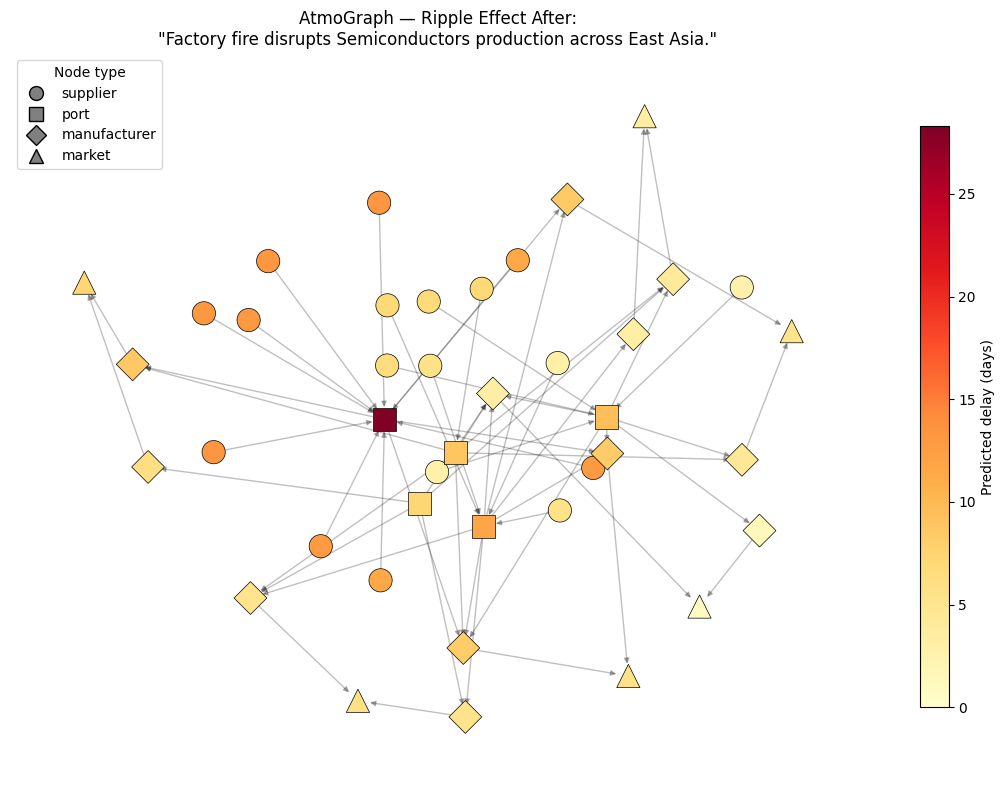

In [10]:
pos = nx.spring_layout(G, seed=SEED, k=0.6)

delay_by_node = {n: pred_delays[idx_of[n]] for n in nodes_list}
vmax = max(delay_by_node.values()) or 1.0
norm = mcolors.Normalize(vmin=0, vmax=vmax)
cmap = cm.get_cmap("YlOrRd")

node_colors = [cmap(norm(delay_by_node[n])) for n in G.nodes()]
node_shapes = {"supplier": "o", "port": "s", "manufacturer": "D", "market": "^"}

fig, ax = plt.subplots(figsize=(11, 8))
for shape in node_shapes:
    nlist = [n for n in G.nodes() if G.nodes[n]["type"] == shape]
    nx.draw_networkx_nodes(
        G, pos, nodelist=nlist, node_shape=node_shapes[shape],
        node_color=[cmap(norm(delay_by_node[n])) for n in nlist],
        node_size=280, edgecolors="black", linewidths=0.5, ax=ax,
    )
nx.draw_networkx_edges(G, pos, alpha=0.25, arrows=True, arrowsize=8, ax=ax)

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.8)
cbar.set_label("Predicted delay (days)")

legend_handles = [plt.Line2D([0], [0], marker=m, color="w", markerfacecolor="grey",
                              markeredgecolor="black", markersize=10, label=t)
                   for t, m in node_shapes.items()]
ax.legend(handles=legend_handles, loc="upper left", title="Node type")
ax.set_title(f"AtmoGraph — Ripple Effect After:\n\"{breaking_news}\"", fontsize=12)
ax.axis("off")
plt.tight_layout()
plt.show()

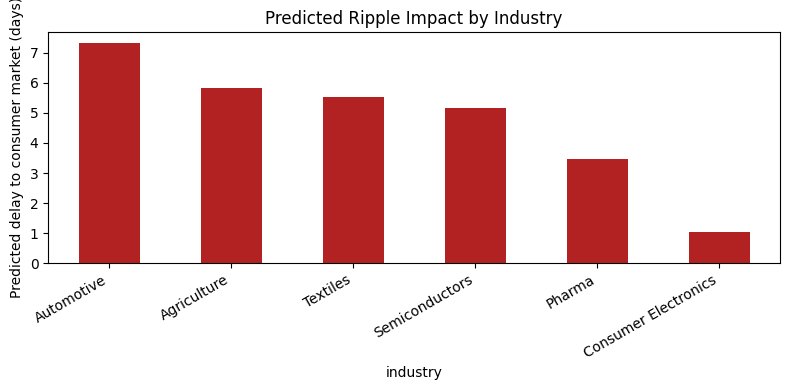

industry
Automotive              7.312532
Agriculture             5.839261
Textiles                5.529077
Semiconductors          5.156468
Pharma                  3.470918
Consumer Electronics    1.043124
Name: predicted_delay_days, dtype: float32

In [11]:
industry_impact = (
    results[results["type"] == "market"]
    .groupby("industry")["predicted_delay_days"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 4))
industry_impact.plot(kind="bar", color="firebrick")
plt.ylabel("Predicted delay to consumer market (days)")
plt.title("Predicted Ripple Impact by Industry")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

industry_impact

## 6. Summary & Production Path

| Component | This notebook | Production (per spec) |
|---|---|---|
| Graph storage | `networkx.DiGraph` (in-memory) | **Neo4j** (Cypher, persisted, queryable) |
| Entity extraction | spaCy `EntityRuler` (rule-based) | Fine-tuned spaCy/HuggingFace NER on live news feeds |
| GNN | Hand-rolled dense GCN in PyTorch | **PyTorch Geometric** (`GCNConv`/`SAGEConv`, sparse, GPU-scaled) |
| Serving | In-notebook function calls | **FastAPI** + **WebSockets** streaming live predictions |
| Frontend | `matplotlib` static plots | **React + D3.js / React Flow**, real-time interactive graph |

**Result:** given a single breaking-news headline, AtmoGraph automatically located the
disruption on the graph, propagated its effect through the network via the trained GNN,
and surfaced which downstream industries and consumer markets are predicted to feel the
impact — the core "ripple effect" prediction from the project brief.
